In [58]:
import matplotlib.pyplot as plt
from pyvi import ViTokenizer
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [59]:
INPUT = 'data/news_vnexpress'

In [60]:
def load() -> tuple[list, list]:
    news = load_files(INPUT,encoding='utf-8')
    return news.data, news.target

In [61]:
def preprocess(X_train, X_test) -> tuple[list, list] :
    news = load_files(INPUT,encoding='utf-8')
    data_set = news.data
    target = news.target
    with open('data/vietnamese-stopwords.txt',encoding='utf-8') as f:
        stopwords = f.readlines()
    def tokenize_vn(text):
        return ViTokenizer.tokenize(text).split()
    for i in range(len(stopwords)):
        stopwords[i] = stopwords[i].strip().replace(' ','_')
    bow = CountVectorizer(stop_words=stopwords,
        tokenizer=tokenize_vn, token_pattern=None)
    tf = Pipeline(steps=[
        ('vec',bow),
        ('idf',TfidfTransformer())
    ])
    return tf.fit_transform(X_train), tf.transform(X_test)

In [62]:
def train_svm(X_train, y_train):
    param_grid = {
        "C": [0.1, 1, 10],
        "kernel": ["linear","rbf"],
    }
    gs = GridSearchCV(
        estimator=SVC(),
        param_grid=param_grid,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )
    gs.fit(X_train, y_train)
    return gs.best_estimator_

In [63]:
def train_random_forest(X_train, y_train):
    param_grid = {
        "n_estimators": [100, 200],
        "min_samples_split": [2, 5]
    }
    gs = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )
    gs.fit(X_train, y_train)
    return gs.best_estimator_

In [64]:
def train_logistic_regression(X_train, y_train):
    param_grid = {
        "C": [0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    }
    gs = GridSearchCV(
        estimator=LogisticRegression(max_iter=1000),
        param_grid=param_grid,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )
    gs.fit(X_train, y_train)
    return gs.best_estimator_

In [65]:
def train_knn(X_train, y_train):
    param_grid = {
        "n_neighbors": [10, 15, 20],
        "metric": ["euclidean", "manhattan"]
    }
    gs = GridSearchCV(
        estimator=KNeighborsClassifier(),
        param_grid=param_grid,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )
    gs.fit(X_train, y_train)
    return gs.best_estimator_

In [66]:
def model_selection(models: dict, X_test, y_test):
    best_model = None
    best_model_name = None
    best_accuracy = 0.0
    for model_name, model in models.items():
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_model_name = model_name
    return best_model, best_model_name, best_accuracy

### Đây là hàm main

In [67]:
data_preprocessed, target = load()
X_train ,X_test, y_train, y_test = train_test_split(data_preprocessed,target,shuffle=True,test_size=0.2,stratify=target)
X_train, X_test = preprocess(X_train, X_test)

In [68]:
models = {
    "SVM": train_svm(X_train, y_train),
    "Random Forest": train_random_forest(X_train,y_train),
    "Logistic Regression": train_logistic_regression(X_train,y_train),
    "KNN": train_knn(X_train,y_train)
}

/Users/nguyenducthien/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/Users/nguyenducthien/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/Users/nguyenducthien/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. A

In [69]:
best_model, best_model_name, best_accuracy = model_selection(models,X_test,y_test)
print("Best Model: ",best_model_name)
print("Accuracy: ",best_accuracy)
print("Parameters:")
for key, value in best_model.get_params().items():
    print(f"  {key}: {value}")

Best Model:  SVM
Accuracy:  0.9552238805970149
Parameters:
  C: 10
  break_ties: False
  cache_size: 200
  class_weight: None
  coef0: 0.0
  decision_function_shape: ovr
  degree: 3
  gamma: scale
  kernel: linear
  max_iter: -1
  probability: False
  random_state: None
  shrinking: True
  tol: 0.001
  verbose: False


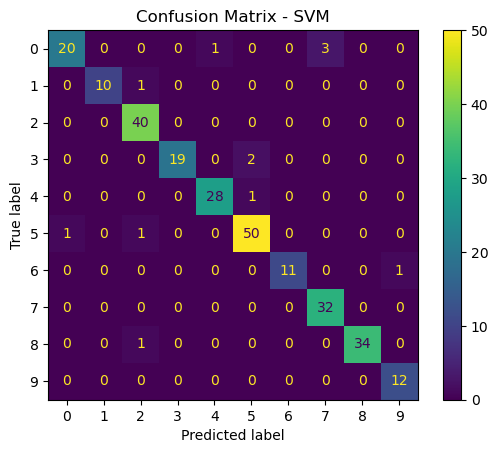

In [70]:
y_pred = best_model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()